In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el archivo (ajusta el nombre si es necesario)
df = pd.read_csv('/content/Anatomia_Parcial1.csv')

# Verificamos que se cargó correctamente
print(df.columns)

Index(['Peso (kg)', 'Altura (cm)', 'Longitud pie', 'Circunferencia cabeza',
       'Unnamed: 4'],
      dtype='object')


KeyError: 21

In [ ]:
df.describe()

,Peso (kg),Altura (cm),Longitud pie,Circunferencia cabeza,Unnamed: 4
count,28.000000,28.000000,28.000000,28.000000,0.0
mean,64.892857,163.321429,25.457143,55.578571,NaN
std,13.955854,10.828815,2.663808,4.261660,NaN
min,47.000000,144.000000,21.000000,44.500000,NaN
25%,55.000000,154.250000,23.750000,54.750000,NaN
50%,63.000000,162.500000,25.000000,56.000000,NaN
75%,72.000000,170.000000,26.250000,57.500000,NaN
max,98.000000,181.000000,33.000000,63.000000,NaN


In [ ]:
#Limpieza
# Borra cualquier fila que tenga al menos un valor nulo
df_limpio = df.dropna()

#'axis=1' le dice a pandas que busque columnas, 'how=all' que solo borre si todo es nulo
df = df.dropna(axis=1, how='all')

print(df.shape)

(58, 4)


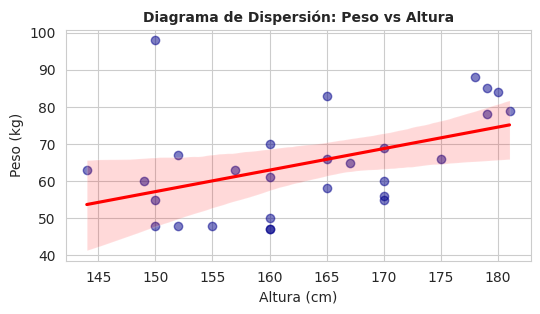

In [ ]:
# Configuramos el estilo visual
sns.set_style("whitegrid")

# Creamos el gráfico de dispersión + línea de regresión
plt.figure(figsize=(6, 3))
sns.regplot(data=df, x='Altura (cm)', y='Peso (kg)',
            scatter_kws={'color': 'darkblue', 'alpha': 0.5},
            line_kws={'color': 'red'})

# Personalización de títulos (como hacías con labs)
plt.title("Diagrama de Dispersión: Peso vs Altura", fontsize=10, fontweight='bold')
plt.xlabel("Altura (cm)")
plt.ylabel("Peso (kg)")

plt.show()

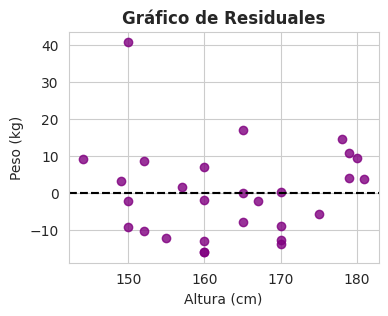

In [ ]:
# Suponiendo que ya tienes tu modelo ajustado
# Si usaste regplot, podemos graficar los residuales directamente:
plt.figure(figsize=(4, 3))
sns.residplot(data=df, x='Altura (cm)', y='Peso (kg)', color="purple")

plt.title("Gráfico de Residuales", fontweight='bold')
plt.axhline(0, color='black', linestyle='--')
plt.show()

In [ ]:
#Eliminando Outlier

# Buscamos la fila donde el peso es muy alto para esa altura
outlier = df[(df['Altura (cm)'] < 155) & (df['Peso (kg)'] > 90)]
print(outlier)

    Peso (kg)  Altura (cm)  Longitud pie  Circunferencia cabeza
20       98.0        150.0          24.0                   60.0


In [ ]:
#Eliminando Outiler

# Eliminamos la fila 20
df_limpio = df.drop(20).reset_index(drop=True)

# Verificamos que ya no esté (opcional)
print(f"Total de filas original: {len(df)}")
print(f"Total de filas ahora: {len(df_limpio)}")

Total de filas original: 58
Total de filas ahora: 57


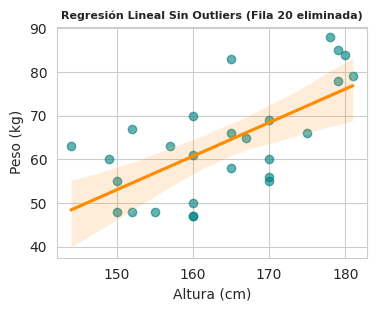

In [ ]:
#Modelo de Regresión Lineal Sin Outlier

plt.figure(figsize=(4,3))
sns.regplot(data=df_limpio, x='Altura (cm)', y='Peso (kg)',
            scatter_kws={'color': 'teal', 'alpha': 0.6},
            line_kws={'color': 'darkorange'})

plt.title("Regresión Lineal Sin Outliers (Fila 20 eliminada)", fontsize=8, fontweight='bold')
plt.xlabel("Altura (cm)")
plt.ylabel("Peso (kg)")
plt.show()

In [ ]:
#Inferencia y valores de los parametros del modelo de regresión lineal simple después de la eliminación del outlier
import statsmodels.api as sm

# 1. Creamos una copia asegurando que no haya NINGÚN nulo en las variables que usaremos
df_final = df_limpio[['Altura (cm)', 'Peso (kg)']].dropna()

# 2. Definimos variables usando la base 100% limpia
X = df_final['Altura (cm)']
y = df_final['Peso (kg)']

# 3. Añadimos la constante y ajustamos el modelo
X = sm.add_constant(X)
modelo_nuevo = sm.OLS(y, X).fit()

# 4. Imprimimos resultados
print(f"Nuevo R-squared: {modelo_nuevo.rsquared:.4f}")
print(modelo_nuevo.summary())

Nuevo R-squared: 0.4286
                            OLS Regression Results                            
Dep. Variable:              Peso (kg)   R-squared:                       0.429
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     18.75
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000211
Time:                        16:59:07   Log-Likelihood:                -98.637
No. Observations:                  27   AIC:                             201.3
Df Residuals:                      25   BIC:                             203.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -62.4233    

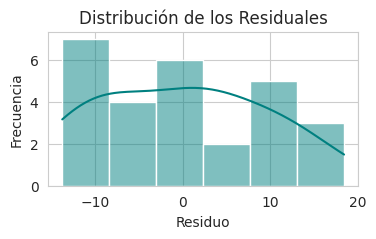

In [ ]:
# Extraemos los residuales del modelo que acabas de correr
residuales = modelo_nuevo.resid

plt.figure(figsize=(4, 2))
sns.histplot(residuales, kde=True, color="teal")
plt.title("Distribución de los Residuales")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
#Prueba de Shapiro Wilk para los residuales
from scipy.stats import shapiro

stat, p_valor = shapiro(residuales)
print(f"Estadístico de Shapiro: {stat:.4f}")
print(f"P-valor: {p_valor:.4f}")

if p_valor > 0.05:
    print("Veredicto: Los residuales siguen una distribución normal (No se rechaza H0)")
else:
    print("Veredicto: Los residuales NO son normales (Se rechaza H0)")

Estadístico de Shapiro: 0.9543
P-valor: 0.2720
Veredicto: Los residuales siguen una distribución normal (No se rechaza H0)
